## Использованные данные

В данной работе применены те же алгоритмы, что и в лекции, но на других наборах данных.

**Бинарная классификация** (вместо датасета wine):
- датасет `breast_cancer` из sklearn
- 2 признака: `mean radius` и `mean texture`
- 569 наблюдений, 2 класса (злокачественная / доброкачественная опухоль)

**Многоклассовая классификация** (вместо MNIST):
- датасет `digits` из sklearn (изображения цифр 8×8)
- 64 признака, 10 классов (цифры 0–9)
- 1797 наблюдений: 80% обучение, 20% тест

# Нейронные сети
# Обучение нейронной сети

Рассмотрим обучение нейронной сети на данных о раке молочной железы. Построим вначале бинарный, а затем мультиклассовый классификатор.

In [137]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
from sklearn.metrics import accuracy_score

## Подготовка данных

Импортируем данные о раке молочной железы, из признаков оставим средний радиус и среднюю текстуру, масштабируем данные.

In [138]:
# импортируем датасет
from sklearn import datasets
data = datasets.load_breast_cancer()

# сформируем датафрейм и добавим целевую переменную
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

# оставим только средний радиус и среднюю текстуру
X = df[['mean radius', 'mean texture']]
y = df['target']

# масштабируем признаки
X = (X - X.mean()) / X.std()

# посмотрим на размерность и имеющиеся классы
df.shape, df.target.unique()

((569, 31), array([0, 1]))

Дополнительно преобразуем датафрейм признаков X в массив Numpy с размерностью 2 x 569 и сделаем целевую переменную y двумерным массивом.

In [139]:
# каждый столбец - это одно наблюдение
X = X.to_numpy().T
X.shape

(2, 569)

In [140]:
y = y.to_numpy().reshape(1, -1)
y.shape

(1, 569)

### Функция активации

In [141]:
# функция активации
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

### Функция потерь

In [142]:
# функция потерь
def objective(y, y_pred):

  y_one_loss = y * np.log(y_pred + 1e-9)
  y_zero_loss = (1 - y) * np.log(1 - y_pred + 1e-9)
  return -np.mean(y_zero_loss + y_one_loss)

Теперь объявим веса и поместим признаки в нейроны скрытого слоя (исключительно ради единообразия терминологии).

### Прямое распространение

In [143]:
# input layer: 2 nodes
# hidden layer 1: 3 nodes
# output layer: 1 node

In [144]:
# зададим точку отсчета
np.random.seed(42)

# инициализируем случайные веса,
# взятые из стандартного нормального распределения
W1 = np.random.randn(3, 2)
W2 = np.random.randn(1, 3)

# найдем количество наблюдений
n = X.shape[1]

# для единообразия терминологии
# поместим признаки в нейроны входного слоя
A1 = X

Последовательно выполним операции умножения весов на нейроны и пропустим результаты через две сигмоиды.

In [145]:
# выполним умножение матриц W1 и A1 и "пропустим" результат через сигмоиду
# в скобках указана итоговая размерность операции
Z1 = np.dot(W1, A1) # (3 x 569)
A2 = sigmoid(Z1) # (3 x 569)

# поступим аналогично с матрицами W2 и A2
Z2 = np.dot(W2, A2) # (1 x 569)
A3 = sigmoid(Z2) # (1 x 569)

# посмотрим, какую вероятность модель выдала для первого наблюдения
A3[:,0]

array([0.71090839])

Для первого наблюдения модель выдала вероятность 0.71, то есть при текущих весах сеть склоняется к классу 1 (доброкачественная опухоль).

Найдем ошибку при текущих весах.

In [146]:
# найдем ошибку при текущих весах
loss = objective(A3, y)
loss

np.float64(10.393199261026274)

Функция потерь при случайных начальных весах равна 10.39 — это стартовая точка до начала обучения. Чем выше значение, тем хуже текущие предсказания модели.

## Код обратного распространения
Продолжим писать код, который мы начали создавать, изучая прямое распространение.

In [147]:
# найдем дельту весов между слоями 3 и 2
W2_delta = A3 - y # (1 x 569)

In [148]:
# обратите внимание, это одно число, как и результат
# третьего слоя A3 (мы выводим первый столбец из 569)
W2_delta[:, 0]

array([0.71090839])

In [149]:
# найдем дельту весов между слоями 1 и 2
W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 569)

In [150]:
# дельта 1 состоит уже из трех чисел, как и скрытый слой нейросети
W1_delta[:, 0]

array([ 0.23730326,  0.04006349, -0.08235989])

In [151]:
# вспомним, что умножение дельты 2 на веса скрытого слоя W2 можно
# считать "промежуточной ошибкой" сети или ошибкой скрытого слоя
E2 = np.dot(W2.T, W2_delta)

# то есть одно число W2_delta мы "распространили" на весь скрытый слой,
# поэтому ошибка состоит из трех чисел
E2[:, 0]

array([ 1.12267564,  0.54557579, -0.33375328])

In [152]:
# наконец найдем частную производную относительно весов W2
W2_derivative = np.dot(W2_delta, A2.T) / n # (1 x 3)
W2_derivative

array([[0.08187518, 0.15414445, 0.0028297 ]])

In [153]:
# и весов W1
# (размерность опять же должна совпадать с размерностью матриц весов)
W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
W1_derivative

array([[ 0.14394206,  0.09513762],
       [ 0.03949709,  0.01355044],
       [-0.0454401 , -0.02663151]])

In [154]:
# обновим веса (скорость обучения положим равной 0,1)
W2 = W2 - 0.1 * W2_derivative
W1 = W1 - 0.1 * W1_derivative

### Обучение модели

Теперь соединим прямое и обратное распространение и с помощью цикла произведем обучение нейронной сети.

In [155]:
np.random.seed(42)

W1 = np.random.randn(3, 2)
W2 = np.random.randn(1, 3)

epochs = 100000
learning_rate = 0.1

n = X.shape[1]

A1 = X

for i in range(epochs):

  # рассчитываем прямое распространение
  Z1 = np.dot(W1, A1) # (3 x 569)
  A2 = sigmoid(Z1) # (3 x 569)

  Z2 = np.dot(W2, A2) # (1 x 569)
  A3 = sigmoid(Z2) # (1 x 569)

  # рассчитываем ошибку
  loss = objective(A3, y)

  # находим дельту весов между слоями 3 и 2
  W2_delta = A3 - y # (1 x 569)
  # находим дельту весов между слоями 2 и 1
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 569)

  # находим частные производные
  W2_derivative = np.dot(W2_delta, A2.T)/n # (1 x 3)
  W1_derivative = np.dot(W1_delta, A1.T)/n # (3 x 569) --> (3 x 2)

  # обновляем веса
  W2 = W2 - learning_rate * W2_derivative
  W1 = W1 - learning_rate * W1_derivative

  # периодически выводим количество итераций и текущую ошибку
  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    # можем добавить паузу для более аккуратного вывода
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 10.393199261026274
-----------------------
Эпоха: 20000
Ошибка: 3.039350027765971
-----------------------
Эпоха: 40000
Ошибка: 3.0267308709259426
-----------------------
Эпоха: 60000
Ошибка: 3.019603880985893
-----------------------
Эпоха: 80000
Ошибка: 3.0143282112574257
-----------------------
Итоговая ошибка 3.010353378322273
Нейросеть успешно обучена


### Прогноз и оценка качества

Сделаем прогноз и оценим качество.

In [156]:
A1 = X

Z1 = np.dot(W1, A1)
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2)
A3 = sigmoid(Z2)

# A3.flatten() делает массив одномерным,
# условие выводит True или False (1 или 0)
y_pred, y_true = A3.flatten() >= 0.5, y.flatten()

In [157]:
W1, W2

(array([[-1.09262651,  0.17555022],
        [-0.14899782,  2.91418666],
        [ 1.10677259, -0.17411998]]),
 array([[10.46095821, -4.66402609, -4.50970053]]))

In [158]:
accuracy_score(y_true, y_pred)

0.9050966608084359

Точность на обучающей выборке составила 90.5%.

## Масштабирование целевой переменной

In [159]:
# в Google Colab уже установлена вторая версия библиотеки Tensorflow,
# которая существенно отличается от первой версии
import tensorflow as tf
tf.__version__

'2.19.0'

В нейросеть мы будем подавать признаки и целевую переменную таким образом, чтобы объекты были строками.

In [160]:
X.T.shape, y.T.shape

((569, 2), (569, 1))

Перейдем к созданию и обучению нейросети.

In [161]:
# зададим две точки отсчета, одну в библиотеке Numpy
np.random.seed(42)
# вторую непосредственно в Tensorflow
tf.random.set_seed(42)

# зададим архитектуру: последовательная модель
model = tf.keras.models.Sequential([
  # с полносвязными слоями
  # также укажем нейроны скрытого и выходного слоев
  # откажемся от смещения
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = False),
  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = False)
])

# зададим особенности стохастического градиентного спуска (SGD)
# в частности, откажемся от импульса
# (подробнее об этом на других занятиях)
sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

# соберем все вместе, дополнительно укажем тип функции потерь и метрику качества
model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

# зададим количество эпох,
# размер batch, после которой мы обновляем веса, равен объему данных (full batch)
model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 569,
          verbose = 0)

In [162]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                │ (569, 3)               │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (569, 1)               │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11 (48.00 B)

 Trainable params: 9 (36.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

Оценим качество.

In [163]:
model.history.history['accuracy'][-1]

0.8963093161582947

Точность модели Keras (~89.6%) незначительно ниже, чем у NumPy-реализации (90.5%). Расхождение объясняется внутренними особенностями вычислений Keras, но оба результата сопоставимы.

## Нейросеть со смещением

In [164]:
# input layer: 2 nodes + bias
# hidden layer: 3 nodes + bias
# output layer: 1 node

In [165]:
np.random.seed(42)

# инициализируем веса
W1 = np.random.randn(3, 2)
# b1 будет иметь размерность 3 х 1,
# потому что распространяется на три нейрона скрытого слоя
b1 = np.zeros((3, 1))

W2 = np.random.randn(1, 3)
b2 = np.zeros((1, 1))

n = X.shape[1]

epochs = 100000
learning_rate = 0.1

A1 = X

for i in range(epochs):
  # 3 х 2 на 2 х 569
  Z1 = np.dot(W1, A1) + b1
  A2 = sigmoid(Z1) # (3 x 130)

  # 1 х 3 на 3 х 569
  Z2 = np.dot(W2, A2) + b2
  A3 = sigmoid(Z2) # (1 x 130)

  loss = objective(A3, y)

  W2_delta = A3 - y # (1 x 130)
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 130)

  # keepdims сохраняет исходную размерность
  # 1 х 569 на 130 х 3
  W2_derivative = np.dot(W2_delta, A2.T) / n # (1 x 3)
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n # (1 x 1)

  # 3 х 130 на 130 х 2
  W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 10.393199261026274
-----------------------
Эпоха: 20000
Ошибка: 2.9355135064751616
-----------------------
Эпоха: 40000
Ошибка: 2.8900204085522834
-----------------------
Эпоха: 60000
Ошибка: 2.8843623830987
-----------------------
Эпоха: 80000
Ошибка: 2.882871186349534
-----------------------
Итоговая ошибка 2.882237041670152
Нейросеть успешно обучена


In [166]:
Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)

y_pred, y_true = A3.flatten() > 0.5, y.flatten()

accuracy_score(y_true, y_pred)

0.9015817223198594

In [167]:
W1, W2

(array([[-2.38592064, -0.09397179],
        [ 0.21544532,  2.29160055],
        [ 2.45009319, -1.28662216]]),
 array([[ 8.5074297 , -4.67799569, -5.447514  ]]))

После 100 000 эпох обучения со смещением выполняем прогноз на обучающей выборке. Точность составила 90.1% — практически идентично сети без смещения (89.6%). На данном датасете добавление bias не дало заметного прироста: два признака (mean radius и mean texture) уже достаточно хорошо разделяют классы, и ограничение «граница через начало координат» не было критичным.

### **TF / Keras**. Добавим смещение в нашу модель в библиотеке Keras.

In [168]:
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True),
  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = True)
])

sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 569,
          verbose = 0)

model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (569, 3)               │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (569, 1)               │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (64.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [169]:
model.history.history['accuracy'][-1]

0.8980667591094971

Точность составила ~89.8% — чуть ниже, чем у NumPy-реализации со смещением (90.5%).

## Инициализация весов нулями

In [170]:
np.random.seed(42)

# создадим списки для учета изменения весов
W1_list, W2_list = [], []

# инициализируем веса нулями
W1 = np.zeros((3, 2))
b1 = np.zeros((3, 1))

W2 = np.zeros((1, 3))
b2 = np.zeros((1, 1))

n = X.shape[1]

epochs = 10000
learning_rate = 0.1

A1 = X

for i in range(epochs):
  Z1 = np.dot(W1, A1) + b1
  A2 = sigmoid(Z1)

  Z2 = np.dot(W2, A2) + b2
  A3 = sigmoid(Z2)

  loss = objective(A3, y)

  W2_delta = A3 - y
  # после первой эпохи, т.к. W2 инициализирована нулями,
  # W1_delta, а значит и W1 будут нулевыми
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2)

  W2_derivative = np.dot(W2_delta, A2.T) / n
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n

  W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n

  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  # запишем веса первой и второй эпохи
  if i in [0,1]:
    W1_list.append(W1)
    W2_list.append(W2)

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(0.5)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 10.361632917973205
-----------------------
Эпоха: 2000
Ошибка: 3.4653376218642227
-----------------------
Эпоха: 4000
Ошибка: 3.3074805137006678
-----------------------
Эпоха: 6000
Ошибка: 3.279136148111039
-----------------------
Эпоха: 8000
Ошибка: 3.2658873223082066
-----------------------
Итоговая ошибка 3.2581224183799398
Нейросеть успешно обучена


In [171]:
W1_list

[array([[0., 0.],
        [0., 0.],
        [0., 0.]]),
 array([[-5.61672786e-05, -3.19437228e-05],
        [-5.61672786e-05, -3.19437228e-05],
        [-5.61672786e-05, -3.19437228e-05]])]

In [172]:
W2_list

[array([[0.00637083, 0.00637083, 0.00637083]]),
 array([[0.01246294, 0.01246294, 0.01246294]])]

## Два скрытых слоя
Добавим второй скрытый слой.

In [173]:
# input layer: 2 nodes + bias
# hidden layer 1: 3 nodes + bias
# hidden layer 2: 3 nodes + bias
# output layer: 1 node

In [174]:
np.random.seed(42)

W1 = np.random.randn(3, 2)
b1 = np.zeros((3, 1))

W2 = np.random.randn(3, 3)
b2 = np.zeros((3, 1))

W3 = np.random.randn(1, 3)
b3 = np.zeros((1, 1))

n = X.shape[1]

epochs = 10000
learning_rate = 0.1

A1 = X

for i in range(epochs):

  Z1 = np.dot(W1, A1) + b1 # (3 x 569)
  A2 = sigmoid(Z1)

  Z2 = np.dot(W2, A2) + b2 # (3 x 569)
  A3 = sigmoid(Z2)

  Z3 = np.dot(W3, A3) + b3 # (1 x 569)
  A4 = sigmoid(Z3)

  loss = objective(A4, y)

  W3_delta = A4 - y # (1 x 569)
  W2_delta = np.dot(W3.T, W3_delta) * A3 * (1 - A3) # (3 x 569)
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (3 x 569)

  # 3 х 130 на 130 х 3
  W3_derivative = np.dot(W3_delta, A3.T) / n # (3 x 3)
  b3_derivative = np.sum(W3_delta, axis = 1, keepdims = True) / n # (1 x 1)

  # 3 х 130 на 130 х 3
  W2_derivative = np.dot(W2_delta, A2.T) / n # (3 x 3)
  b2_derivative = np.sum(W2_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W1_derivative = np.dot(W1_delta, A1.T) / n # (3 x 2)
  b1_derivative = np.sum(W1_delta, axis = 1, keepdims = True) / n # (3 x 1)

  W3 = W3 - learning_rate * W3_derivative
  b3 = b3 - learning_rate * b3_derivative
  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')
    time.sleep(1)

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 11.213839404488477
-----------------------
Эпоха: 2000
Ошибка: 3.299661396634228
-----------------------
Эпоха: 4000
Ошибка: 3.070609722180131
-----------------------
Эпоха: 6000
Ошибка: 3.003992294171993
-----------------------
Эпоха: 8000
Ошибка: 2.9720428764263156
-----------------------
Итоговая ошибка 2.950982360670348
Нейросеть успешно обучена


In [175]:
Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)
Z3 = np.dot(W3, A3) + b3
A4 = sigmoid(Z3)

y_pred, y_true = A4.flatten() > 0.5, y.flatten()

accuracy_score(y_true, y_pred)

0.8998242530755711

Сравним с моделью в **Keras**.

In [176]:
np.random.seed(42)
tf.random.set_seed(42)

model = tf.keras.models.Sequential([
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True),
  tf.keras.layers.Dense(3, activation = 'sigmoid', use_bias = True),
  tf.keras.layers.Dense(1, activation = 'sigmoid', use_bias = True)
])

sgd = tf.keras.optimizers.SGD(learning_rate = 0.1,
                              momentum = 0.,
                              nesterov = False)

model.compile(optimizer = sgd,
              loss = 'binary_crossentropy',
              metrics = ['accuracy'])

model.fit(X.T, y.T,
          epochs = 1000,
          batch_size = 569,
          verbose = 0)

model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                │ (569, 3)               │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (569, 3)               │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (569, 1)               │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27 (112.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [177]:
model.history.history['accuracy'][-1]

0.8875219821929932

NumPy-реализация: 90.0% | Keras: 88.8%

Добавление второго скрытого слоя не дало прироста точности по сравнению с однослойной сетью (~90%). На простом двумерном датасете усложнение архитектуры не помогает — модель и так близка к своему потолку с этими признаками

## Многоклассовая классификация

### Функции активации
Как видно на графике, мы будем использовать сигмоиду для промежуточных слоев и softmax для выходного слоя.

In [178]:
def sigmoid(z):
  s = 1 / (1 + np.exp(-z))
  return s

In [179]:
def softmax(z):
  # на выходном слое тензор будет иметь размерность 10 х n,
  # поэтому складывать мы будем по столбцам
  z = z - np.max(z, axis = 0, keepdims = True)
  numerator = np.exp(z)
  denominator = np.sum(numerator, axis = 0, keepdims = True)
  softmax = numerator / denominator
  return softmax

### Функция потерь
Функцией потерь будет категориальная кросс-энтропия.

In [180]:
def cross_entropy(probs, y_enc, epsilon = 1e-9):
  # опять же, так как softmax выдаст тензор 10 х n
  # количество наблюдений содержится в атрибуте shape[1]
  n = probs.shape[1]
  ce = -np.sum(y_enc * np.log(probs + epsilon)) / n

  return ce

## Обратное распространение

### Подготовка данных

Используем датасет digits из библиотеки sklearn (8×8 изображения цифр, 64 признака, 10 классов). Разобьем данные на обучающую и тестовую выборки.

In [181]:
def ohe(y):
  examples, features = y.shape[0], len(np.unique(y))
  zeros_matrix = np.zeros((examples, features))
  for i, (row, digit) in enumerate(zip(zeros_matrix, y)):
    zeros_matrix[i][digit] = 1

  return zeros_matrix

In [182]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

digits_data = load_digits()
X_all = digits_data.data   # (1797, 64)
y_all = digits_data.target # (1797,)

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

In [183]:
X_train = 2. * (X_train_raw - np.min(X_train_raw)) / np.ptp(X_train_raw) - 1
X_test  = 2. * (X_test_raw  - np.min(X_test_raw))  / np.ptp(X_test_raw)  - 1

X_train = X_train.T  # (64, n_train)
X_test  = X_test.T   # (64, n_test)

y_train_enc, y_test_enc = ohe(y_train).T, ohe(y_test).T

X_train.shape, y_train_enc.shape

((64, 1437), (10, 1437))

### Обучение модели

In [184]:
np.random.seed(33)

W1 = np.random.randn(32, 64)
b1 = np.zeros((32, 1))

W2 = np.random.randn(32, 32)
b2 = np.zeros((32, 1))

W3 = np.random.randn(10, 32)
b3 = np.zeros((10, 1))

n = X_train.shape[1]

epochs = 2000
learning_rate = 0.1
loss_history = []

A1 = X_train

for i in range(epochs):

  # 32 x 64 на 64 x n --> 32 x n
  Z1 = np.dot(W1, A1) + b1
  A2 = sigmoid(Z1)

  # 32 x 32 на 32 x n --> 32 x n
  Z2 = np.dot(W2, A2) + b2
  A3 = sigmoid(Z2)

  # 10 x 32 на 32 x n --> 10 x n
  Z3 = np.dot(W3, A3) + b3
  A4 = softmax(Z3)

  loss = cross_entropy(A4, y_train_enc)

  W3_delta = A4 - y_train_enc # (10 x n)
  W2_delta = np.dot(W3.T, W3_delta) * A3 * (1 - A3) # (32 x n)
  W1_delta = np.dot(W2.T, W2_delta) * A2 * (1 - A2) # (32 x n)

  # 10 x n на n x 32 --> 10 x 32
  W3_derivative = np.dot(W3_delta, A3.T) / n
  b3_derivative = np.sum(W3_delta, axis=1, keepdims=True) / n # (10 x 1)

  # 32 x n на n x 32 --> 32 x 32
  W2_derivative = np.dot(W2_delta, A2.T) / n
  b2_derivative = np.sum(W2_delta, axis=1, keepdims=True) / n # (32 x 1)

  # 32 x n на n x 64 --> 32 x 64
  W1_derivative = np.dot(W1_delta, A1.T) / n
  b1_derivative = np.sum(W1_delta, axis=1, keepdims=True) / n # (32 x 1)

  W3 = W3 - learning_rate * W3_derivative
  b3 = b3 - learning_rate * b3_derivative
  W2 = W2 - learning_rate * W2_derivative
  b2 = b2 - learning_rate * b2_derivative
  W1 = W1 - learning_rate * W1_derivative
  b1 = b1 - learning_rate * b1_derivative

  loss_history.append(loss)

  if i % (epochs / 5) == 0:
    print('Эпоха:', i)
    print('Ошибка:', loss)
    print('-----------------------')

print('Итоговая ошибка', loss)
print('Нейросеть успешно обучена')

Эпоха: 0
Ошибка: 8.135873538857217
-----------------------
Эпоха: 400
Ошибка: 0.6622588532063077
-----------------------
Эпоха: 800
Ошибка: 0.3588344088545037
-----------------------
Эпоха: 1200
Ошибка: 0.24126268264838183
-----------------------
Эпоха: 1600
Ошибка: 0.17890263709672755
-----------------------
Итоговая ошибка 0.14122093979999623
Нейросеть успешно обучена


### Прогноз и оценка качества

Сделаем прогноз и оценку качества на обучающей выборке

In [185]:
Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)
Z3 = np.dot(W3, A3) + b3
A4 = softmax(Z3)

In [186]:
y_pred = np.argmax(A4, axis = 0)
y_pred[:4]

array([6, 0, 0, 3])

In [187]:
accuracy_score(y_train, y_pred)

0.9700765483646486

Теперь на тестовых данных

In [188]:
A1 = X_test

Z1 = np.dot(W1, A1) + b1
A2 = sigmoid(Z1)
Z2 = np.dot(W2, A2) + b2
A3 = sigmoid(Z2)
Z3 = np.dot(W3, A3) + b3
A4 = softmax(Z3)

y_pred = np.argmax(A4, axis=0)

accuracy_score(y_test, y_pred)

0.9361111111111111

Обучающая выборка: 97.0%                                                                              

Тестовая выборка:  93.6%

Разрыв в ~3.4% указывает на лёгкое переобучение: модель чуть лучше запомнила обучающие примеры, чем научилась обобщать. Для NumPy-сети с 2000 эпохами и полным градиентным спуском это ожидаемо.

Результат 93.6% на тестовой выборке — хороший показатель

Дополнительно оценим изменение уровня ошибки. Когда мы используем все имеющиеся данные для расчета градиента, «скачков» на графике быть не должно, ошибка должна постоянно уменьшаться.

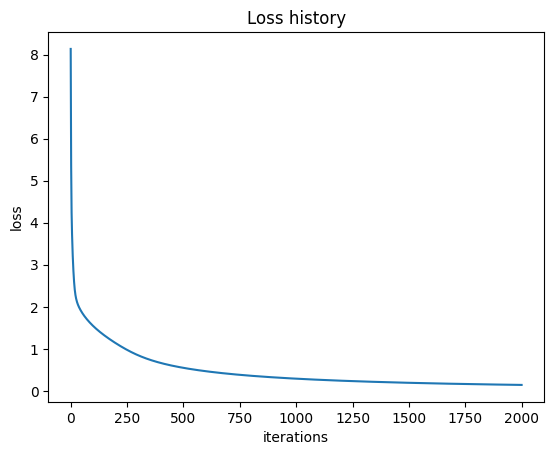

In [189]:
plt.plot(loss_history)
plt.title('Loss history')
plt.xlabel('iterations')
plt.ylabel('loss');